## 1. Data exploration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
from wordcloud import WordCloud
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv('data/reddit_posts.csv')

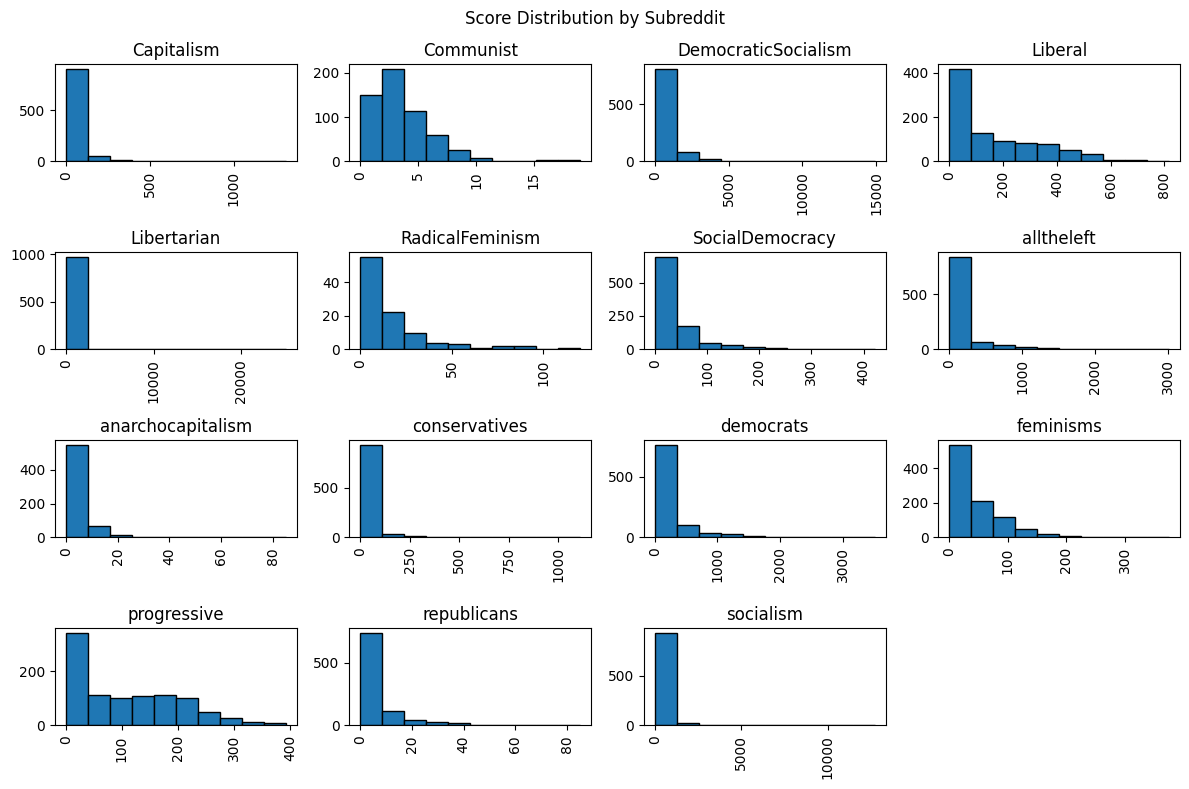

In [3]:

df['Score'].hist(by=df['Subreddit'], edgecolor='black', figsize=(12, 8))

plt.suptitle('Score Distribution by Subreddit')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


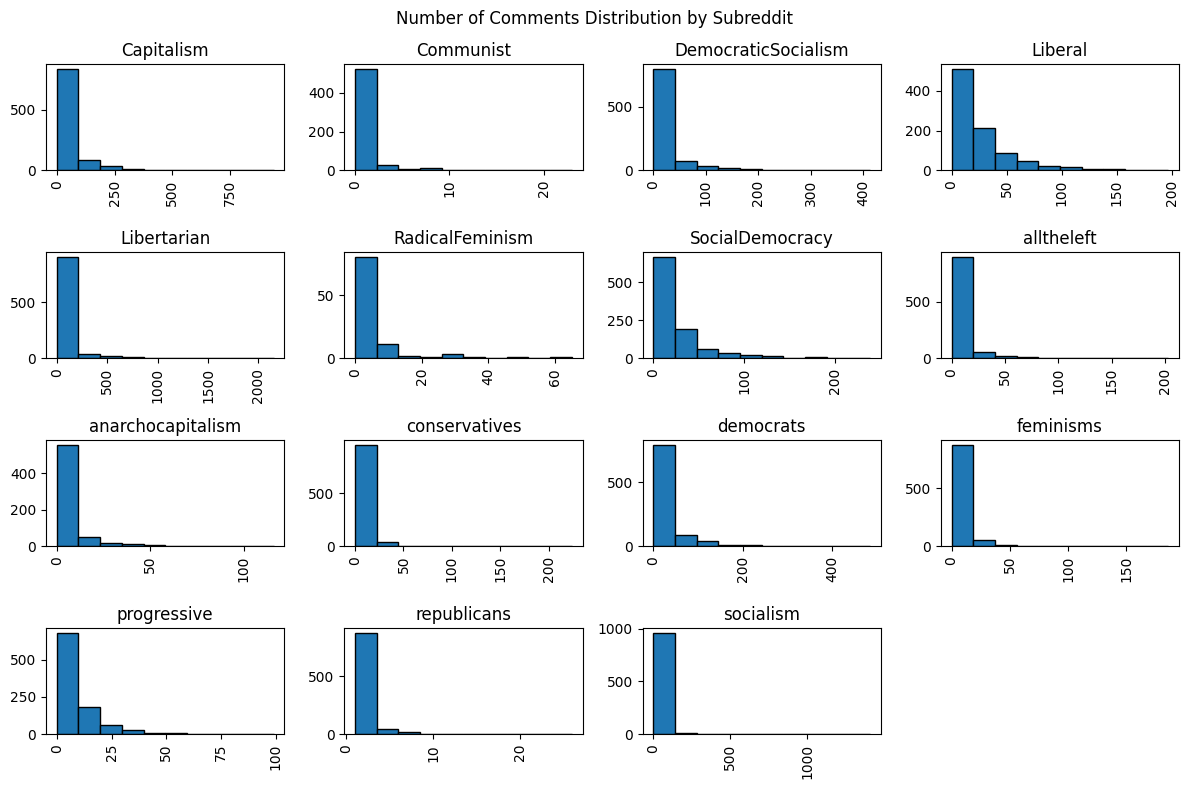

In [4]:
df['Num of Comments'].hist(by=df['Subreddit'], edgecolor='black', figsize=(12, 8))

plt.suptitle('Number of Comments Distribution by Subreddit')
plt.xlabel('Comments')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 2. Data preprocessing

### 2.1 removing urls, and standardising time

In [5]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')
df = df.rename(columns={"Title": "title", "Text": "selftext"})
combined = df['title'].fillna('') + ' ' + df['selftext'].fillna('')
url_pattern = r'https?://\S+'
has_url = combined.str.contains(url_pattern)
print(f"{has_url.sum()} posts contain URLs out of {len(df)} total")

# remove URLs from title and selftext
df['title']    = df['title'].str.replace(url_pattern, '', regex=True)
df['selftext'] = df['selftext'].str.replace(url_pattern, '', regex=True)

656 posts contain URLs out of 12854 total


### 2.2 removing stopwords and short tokens

In [6]:
# stop words list
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_str(text):
    if pd.isna(text):
        return ""
    # lowercase
    text = text.lower()
    # remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # split, filter out short tokens & stop-words, then re-join
    tokens = text.split()
    tokens = [w for w in tokens if len(w) >= 3 and w not in stop_words]
    return " ".join(tokens)

# Apply to title and body, storing cleaned strings
df['title']  = df['title'].apply(clean_str)
df['selftext']   = df['selftext'].apply(clean_str)


### 2.3 lemmatization
To download the model, use 
```py
python -m spacy download en_core_web_sm
```

In [7]:
# if we want to lemmatize
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser","ner","textcat"]  # only need tokenizer, tagger, lemmatizer
)

def clean_str(text: str) -> str:
    if pd.isna(text):
        return ""
    # lowercase & strip non-letters
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    # b) apply spaCy pipeline
    doc = nlp(text)

    # c) filter & lemmatize
    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha             # skip punctuation/numbers
           and not token.is_stop         # skip spaCy’s built-in stop words
           and len(token.lemma_) >= 3    # skip very short lemmas
    ]

    # d) re-join into a cleaned string
    return " ".join(lemmas)

# Apply to your DataFrame in exactly the same way:
df["title"]    = df["title"].apply(clean_str)
df["selftext"] = df["selftext"].apply(clean_str)

## 3. Topic Modelling

In [8]:
list(df.columns)


['title',
 'Political Lean',
 'Score',
 'Id',
 'Subreddit',
 'URL',
 'Num of Comments',
 'selftext',
 'Date Created']

In [9]:
df.Subreddit.value_counts()

Subreddit
conservatives          1000
alltheleft              997
SocialDemocracy         997
Libertarian             975
Capitalism              975
socialism               975
progressive             974
republicans             948
democrats               941
feminisms               935
DemocraticSocialism     922
Liberal                 904
anarchocapitalism       637
Communist               574
RadicalFeminism         100
Name: count, dtype: int64

### 3.1 prepare the docs and labels for prediction

In [12]:
# Combine the 'title' and 'selftext'
docs = (df['title'].fillna('') + ' ' + df['selftext'].fillna('')).tolist()

# Encode Subreddit as integers
le = LabelEncoder()
y = le.fit_transform(df['Subreddit'])
subreddit_names = le.classes_


### 3.2 Fit BERTopic and Bet Topic Probabilities


In [14]:
topic_model = BERTopic(calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)


2025-06-02 17:17:05,528 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/402 [00:00<?, ?it/s]

2025-06-02 17:17:46,405 - BERTopic - Embedding - Completed ✓
2025-06-02 17:17:46,406 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-02 17:17:49,358 - BERTopic - Dimensionality - Completed ✓
2025-06-02 17:17:49,359 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-02 17:18:01,986 - BERTopic - Cluster - Completed ✓
2025-06-02 17:18:01,990 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-02 17:18:02,266 - BERTopic - Representation - Completed ✓


## 4. Predicting Subreddit based on Topic Distribution

### 4.1 Predict Subreddit based on Topic distribution


5-fold CV Macro F1: 0.262 ± 0.019
                     precision    recall  f1-score   support

         Capitalism       0.25      0.57      0.35       195
          Communist       0.56      0.17      0.26       115
DemocraticSocialism       0.21      0.07      0.10       184
            Liberal       0.22      0.14      0.17       181
        Libertarian       0.46      0.13      0.21       195
    RadicalFeminism       0.00      0.00      0.00        20
    SocialDemocracy       0.32      0.45      0.37       200
         alltheleft       0.23      0.27      0.24       199
  anarchocapitalism       0.64      0.11      0.19       127
      conservatives       0.32      0.41      0.36       200
          democrats       0.45      0.30      0.36       188
          feminisms       0.65      0.70      0.67       187
        progressive       0.18      0.46      0.26       195
        republicans       0.29      0.16      0.20       190
          socialism       0.28      0.19      0.23

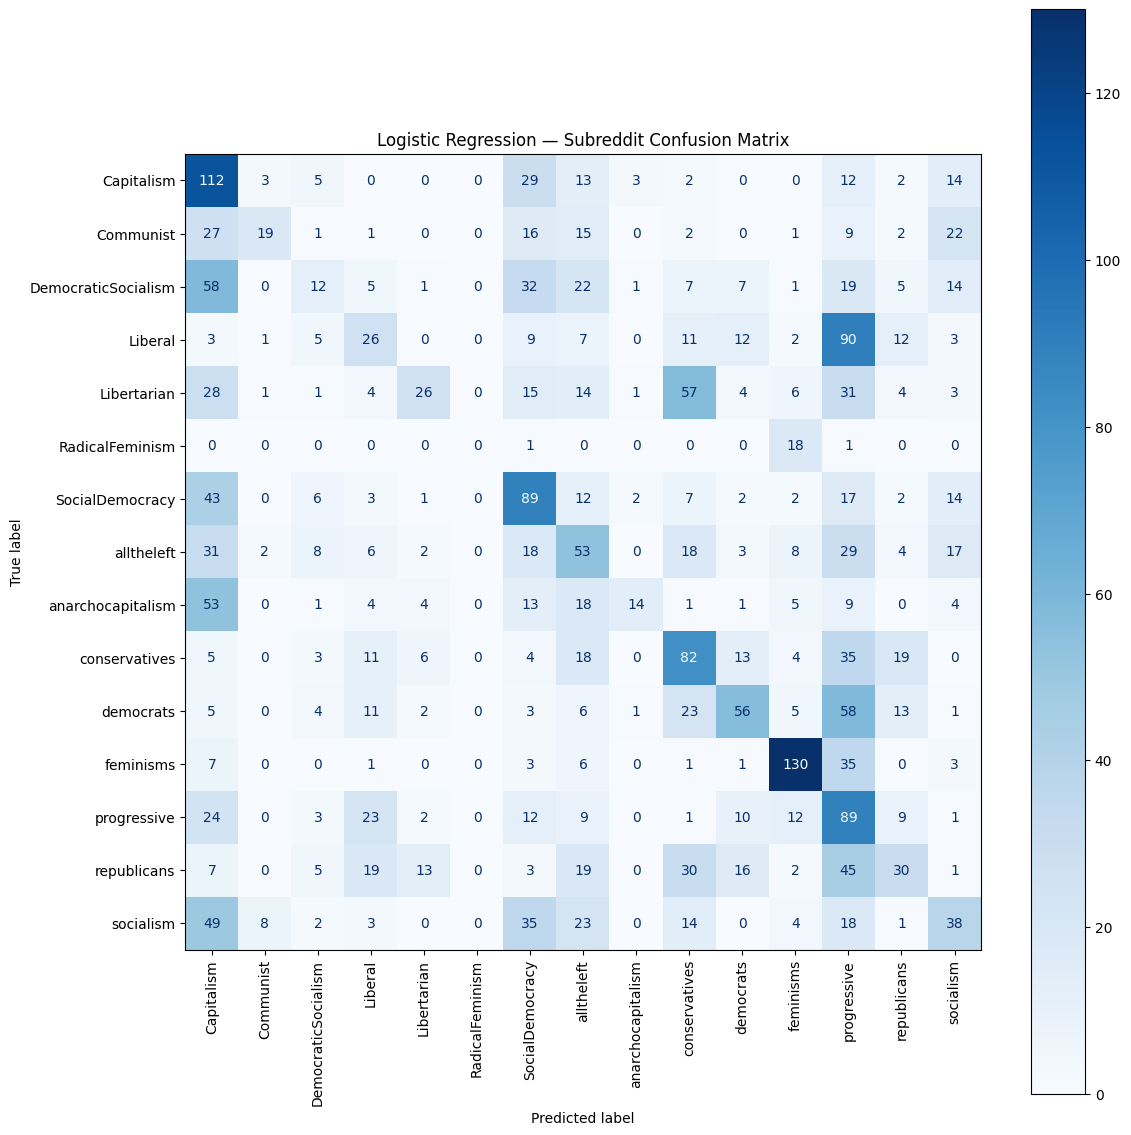

In [15]:
X = np.array(probs)  # shape: (n_docs, n_topics)


# 3. Evaluate with 5-Fold Cross-Validation (Macro F1)
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
f1_scores = cross_val_score(clf, X, y, cv=5, scoring="f1_macro")
print(f"5-fold CV Macro F1: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=subreddit_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=subreddit_names)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90)
plt.title("Logistic Regression — Subreddit Confusion Matrix")
plt.tight_layout()
plt.show()


The predictor with only topics is not very performant.

### 4.2 Find Top Topics for Each Subreddit

In [17]:

# probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
# probs_df["subreddit"] = y

# mean_by_subreddit = probs_df.groupby("subreddit").mean()

# # For each subreddit, get topics with highest mean probability
# top_n = 5
# for idx, subreddit in enumerate(subreddit_names):
#     top_topics = mean_by_subreddit.loc[idx].nlargest(top_n).index.tolist()
#     print(f"\nTop topics for {subreddit}: {top_topics}")
#     for tid in top_topics:
#         print(f"  === Topic {tid} ===")
#         for word, score in topic_model.get_topic(tid):
#             print(f"    {word:15} {score:.4f}")


## 5. Information Content of Topics in Subreddits

### 5.1 Compute Topic Distribution Across Subreddits

In [19]:
# DataFrame: each row is a document, columns are topic probabilities, plus 'Subreddit'
probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
probs_df['Subreddit'] = df['Subreddit'].values

# Compute the mean probability of each topic in each subreddit
topic_by_sub = probs_df.groupby('Subreddit').mean().T  # shape: n_topics x n_subreddits

# Normalize so each topic's distribution across subreddits sums to 1
topic_by_sub_norm = topic_by_sub.div(topic_by_sub.sum(axis=1), axis=0)


### 5.2 Compute Information Content (Negative Entropy)

In [20]:
def entropy(p):
    p = p[p > 0]  # avoid log(0)
    return -np.sum(p * np.log2(p))

n_subreddits = topic_by_sub_norm.shape[1]
max_entropy = np.log2(n_subreddits)

info_content = topic_by_sub_norm.apply(entropy, axis=1)
info_content = max_entropy - info_content  # Higher = more informative


### 5.3 Select the 10 Most Informative Topics

Top 10 informative topics: [108, 104, 1, 8, 83, 90, 10, 0, 5, 3]


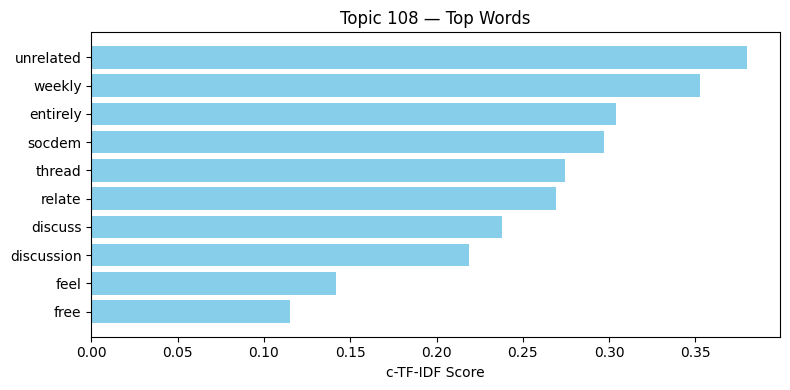

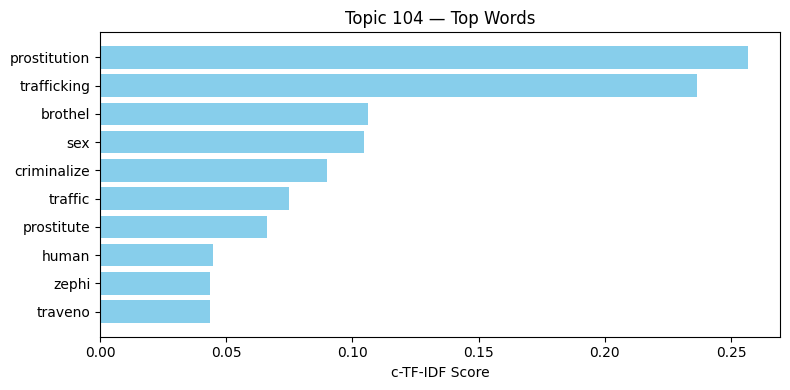

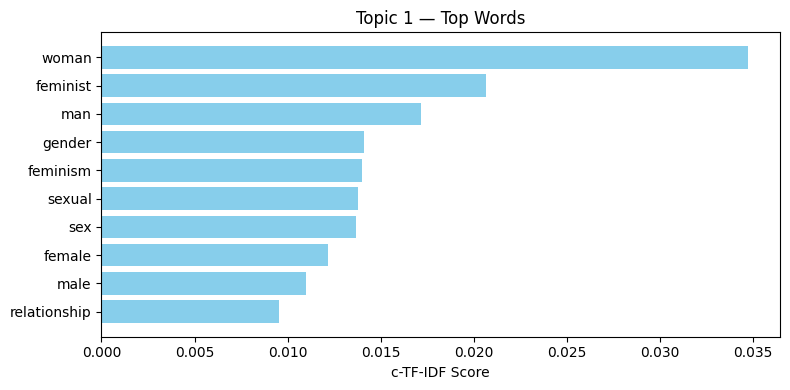

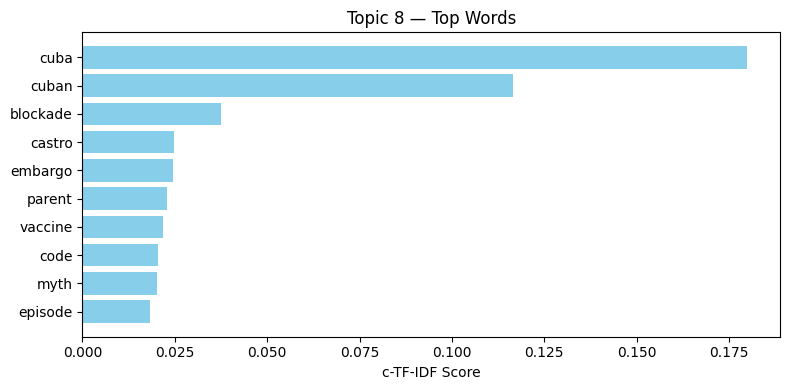

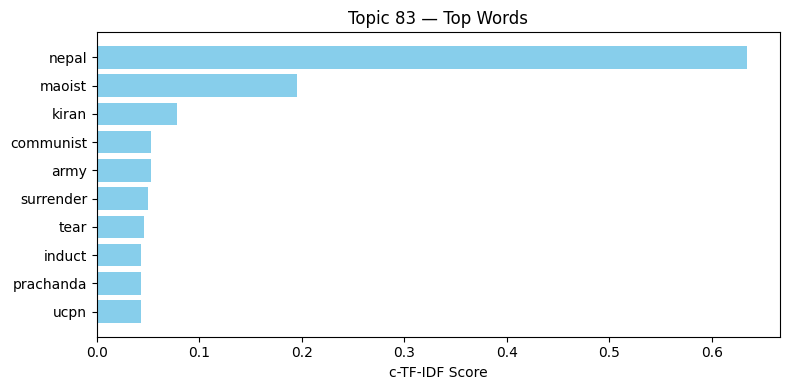

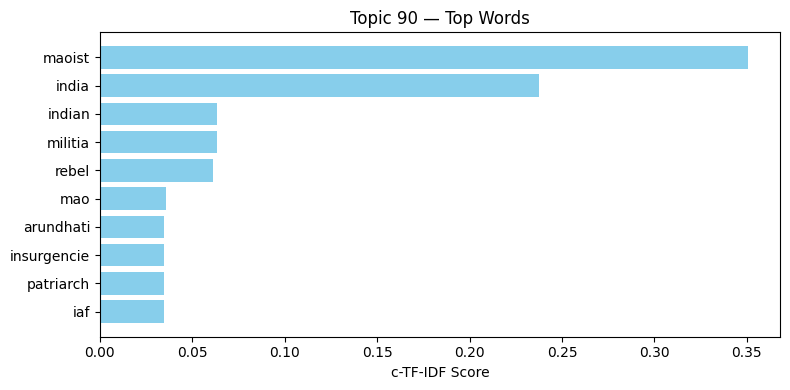

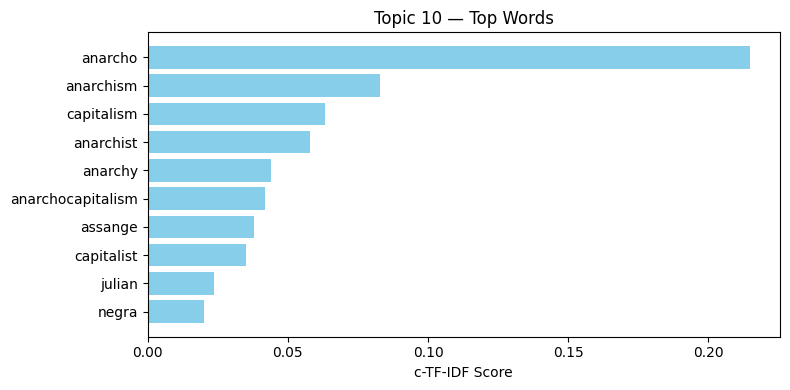

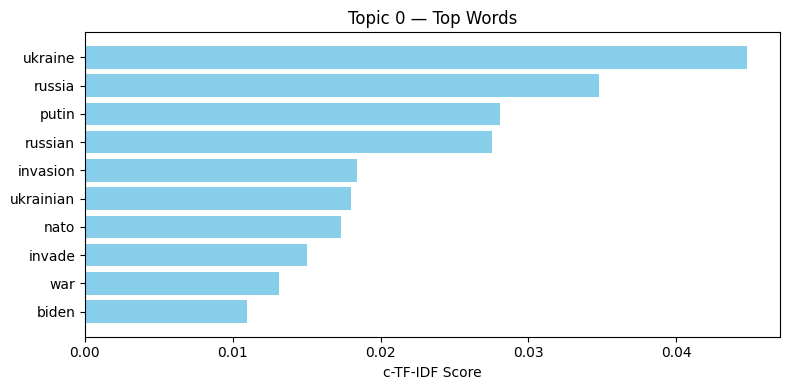

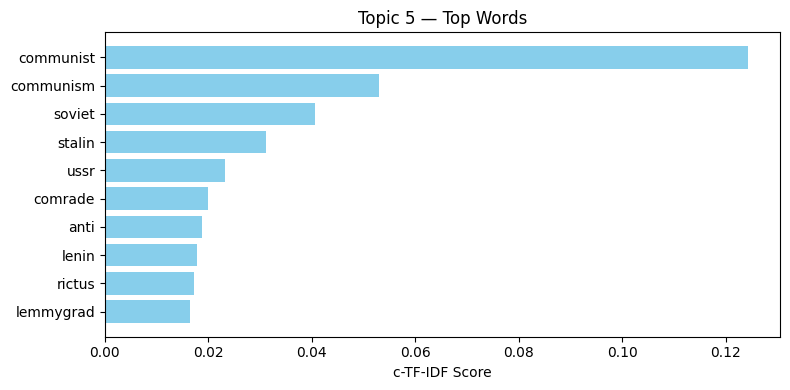

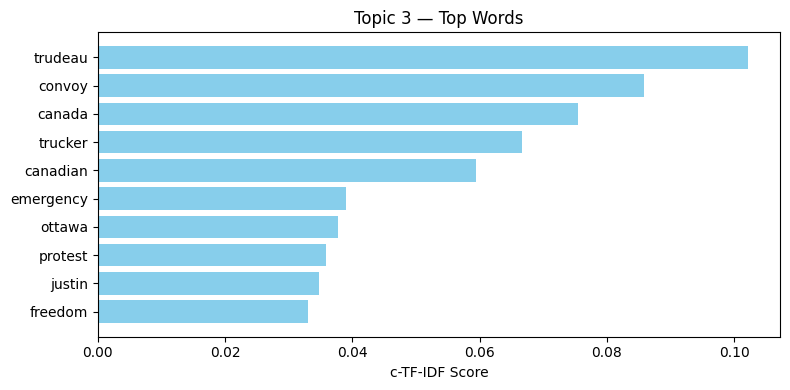

In [23]:
n_words = 10  # Number of top words to display per topic

top_topics = info_content.nlargest(n_words).index.tolist()
print(f"Top {n_words} informative topics:", top_topics)
for tid in top_topics:
    words_scores = topic_model.get_topic(tid)[:n_words]  # List of (word, score) tuples
    words, scores = zip(*words_scores)
    
    plt.figure(figsize=(8, 4))
    plt.barh(words, scores, color='skyblue')
    plt.xlabel("c-TF-IDF Score")
    plt.title(f"Topic {tid} — Top Words")
    plt.gca().invert_yaxis()  # Highest score at the top
    plt.tight_layout()
    plt.show()

### 5.4 Plot the Distribution Amongst Subreddits

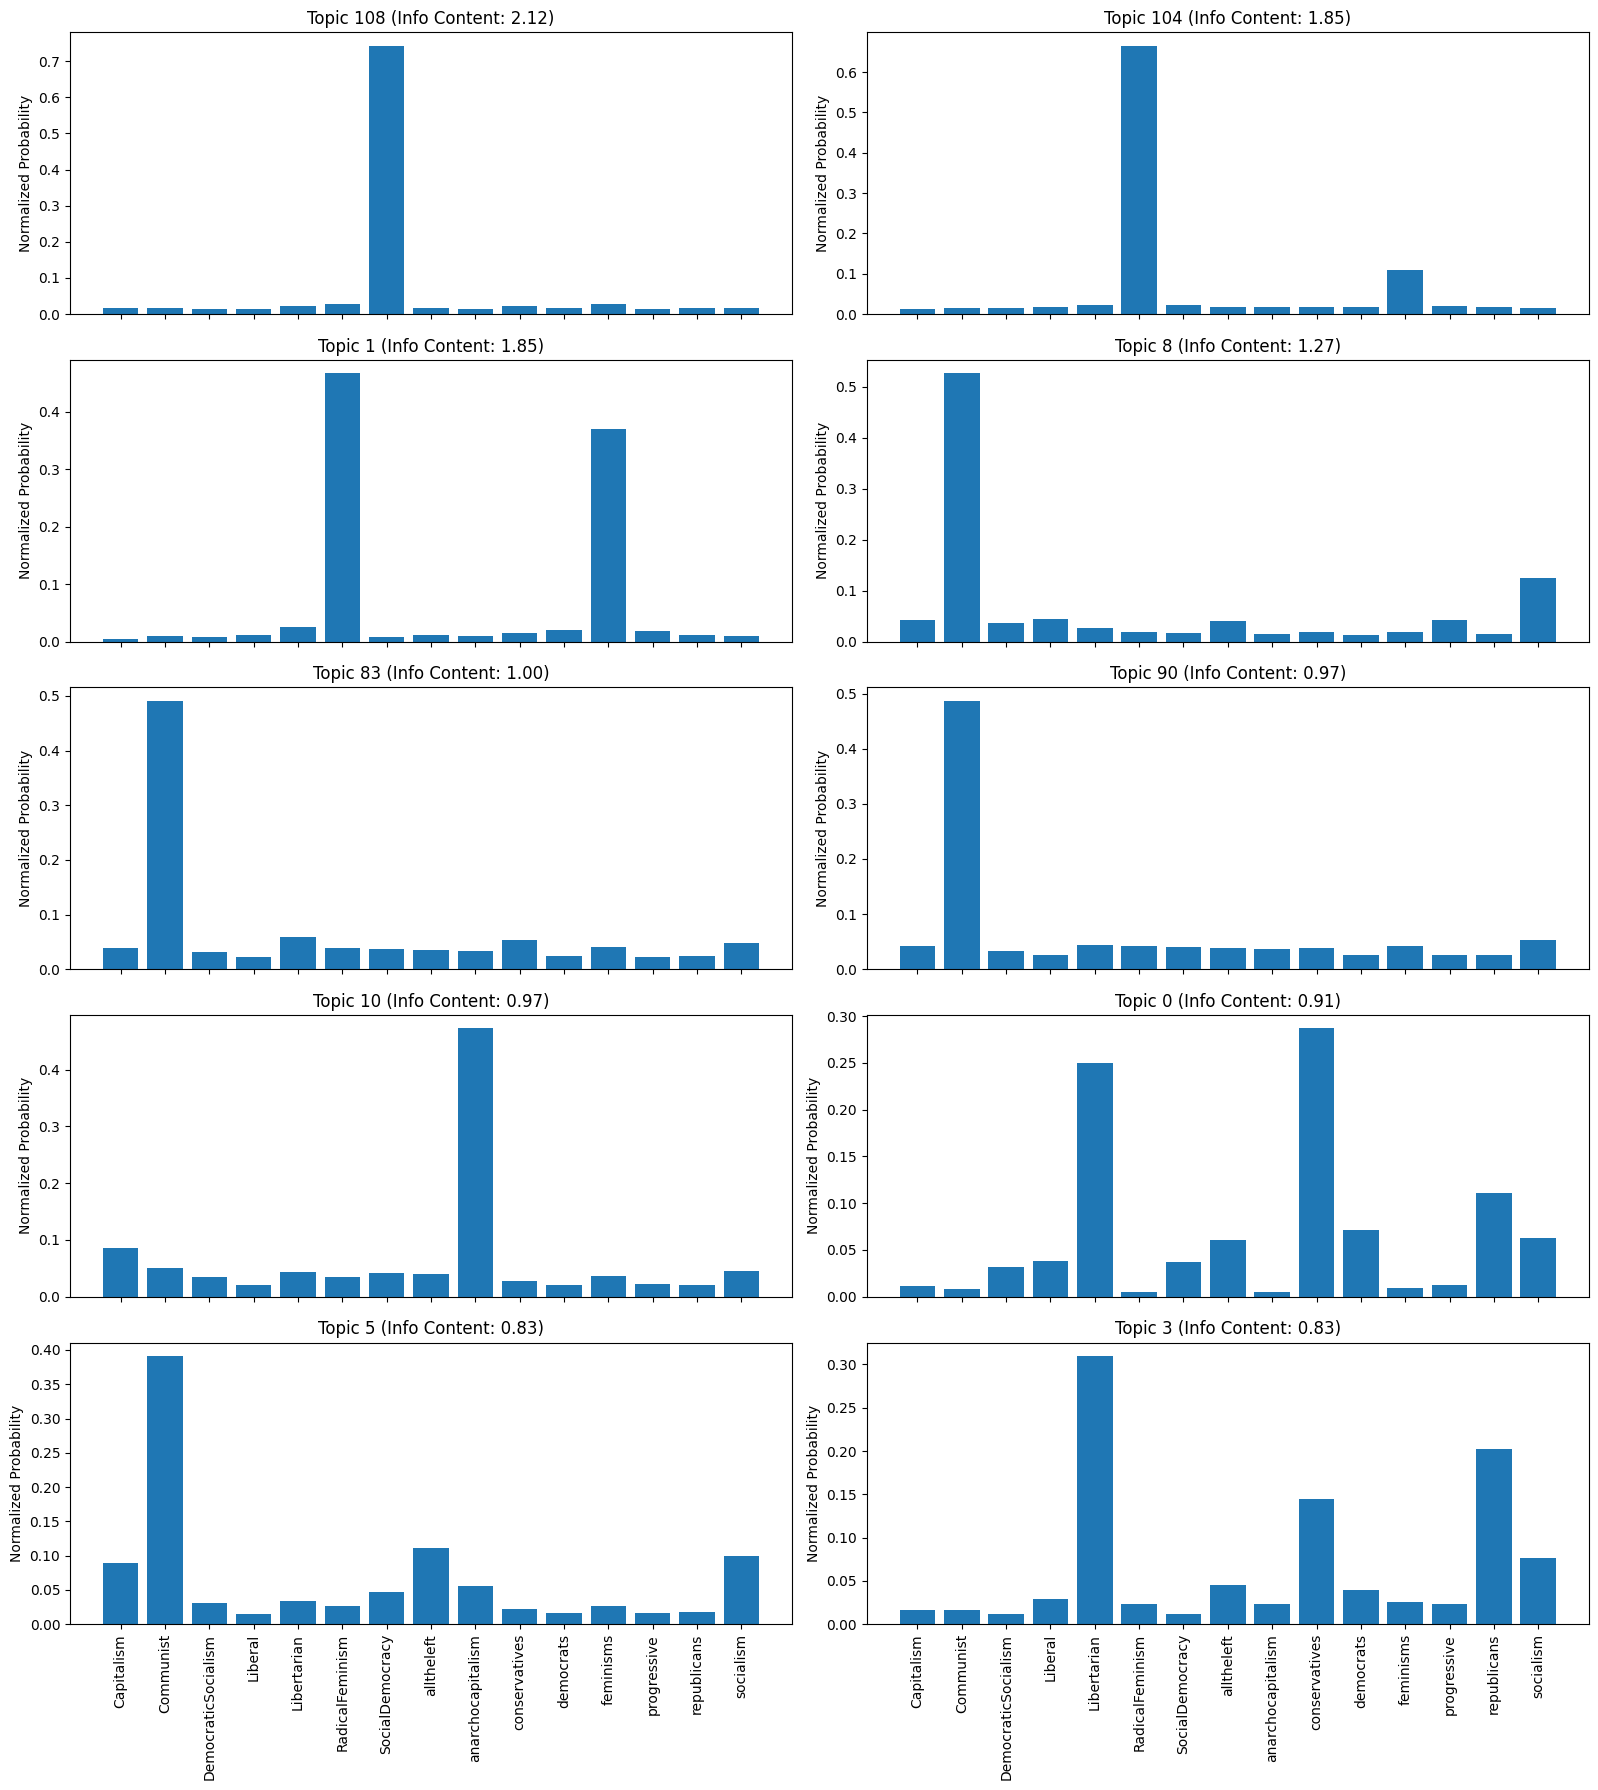

In [22]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for i, tid in enumerate(top_topics):
    topic_dist = topic_by_sub_norm.loc[tid]
    axes[i].bar(topic_dist.index, topic_dist.values)
    axes[i].set_title(f"Topic {tid} (Info Content: {info_content[tid]:.2f})")
    axes[i].set_ylabel("Normalized Probability")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


### 5.5 Distribution of Topic Information

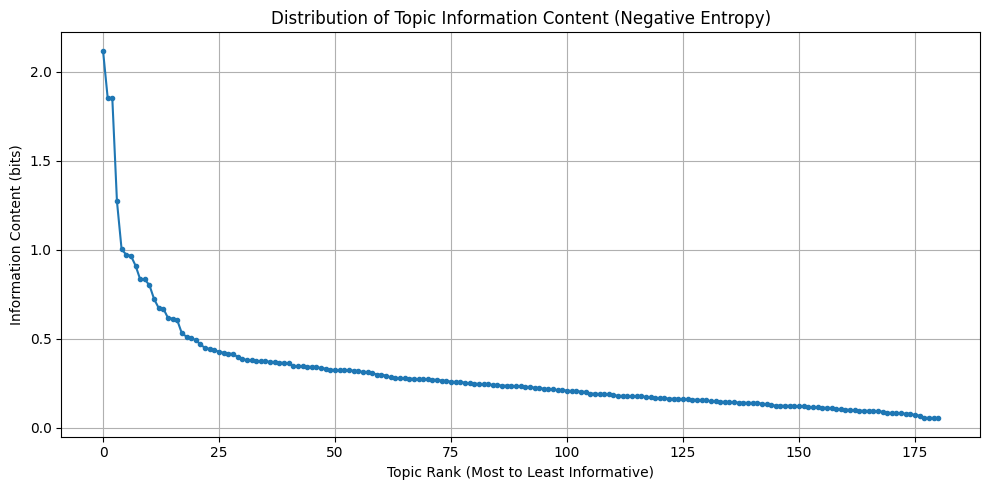

In [25]:
# info_content is a pandas Series: index=topic_id, value=information content (negative entropy)
sorted_info = info_content.sort_values(ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(sorted_info.values, marker='.')
plt.title("Distribution of Topic Information Content (Negative Entropy)")
plt.xlabel("Topic Rank (Most to Least Informative)")
plt.ylabel("Information Content (bits)")
plt.grid(True)
plt.tight_layout()
plt.show()

Not all topics are very Informative. 

## 6. Predicting Subreddits based on Most Informative Subbredits
This approach is directly inspired by the TextNetTopics methodology, which recommends scoring and selecting the most discriminative topics for classification


https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2022.893378/full   

https://www.nature.com/articles/s41598-024-74022-2    

https://www.mdpi.com/2076-3417/14/19/8914    



### 6.1 Rank Topics by Information Content

In [26]:
sorted_topic_ids = info_content.sort_values(ascending=False).index.tolist()

### 6.2 Evaluate Classifier Performance with 1 to 100 Most Informative Topics

In [27]:
max_k = 100
scores = []

for k in range(1, max_k + 1):
    top_k = sorted_topic_ids[:k]
    X_k = probs[:, top_k]  # select columns for top-k topics
    clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
    # Use macro F1 for multiclass
    f1 = cross_val_score(clf, X_k, y, cv=5, scoring="f1_macro").mean()
    scores.append(f1)

### 6.3 Plot Performance Evolution

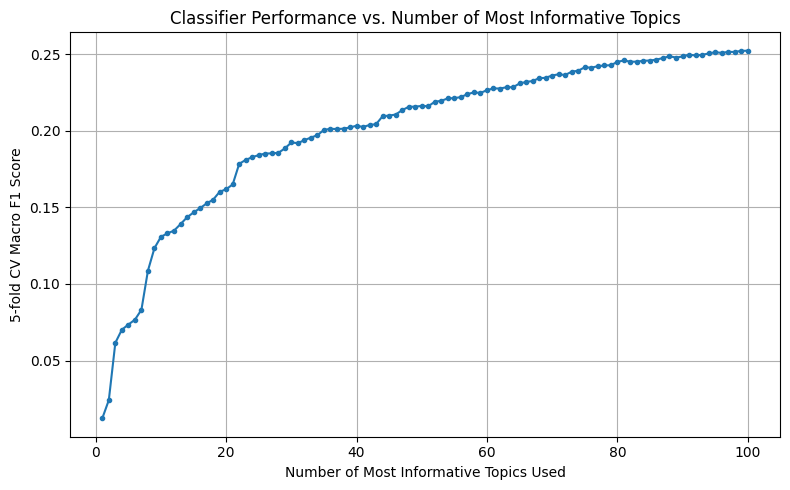

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k + 1), scores, marker='.')
plt.xlabel('Number of Most Informative Topics Used')
plt.ylabel('5-fold CV Macro F1 Score')
plt.title('Classifier Performance vs. Number of Most Informative Topics')
plt.grid(True)
plt.tight_layout()
plt.show()
